# 04 · Walk-Forward Modeling (Cross-Sectional Ranking)

## 0 · Setup

In [12]:
import sys, logging, warnings
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s | %(name)s | %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning)
log = logging.getLogger('models')

from src.utils.io import save, load
from src.config import load_config, get_feature_cols, split_feature_cols
from src.splits import make_expanding_splits
from src.models import walk_forward_compare, build_ensemble, get_models

cfg = load_config(ROOT / 'configs' / 'base.yaml')
print(f'ROOT     : {ROOT}')
print(f'horizon  = {cfg.labeling.horizon}')
print(f'top_k    = {cfg.strategy.top_k}')


ROOT     : C:\Users\H13P\Downloads\ML_Trading_Strategy_Nasdaq100
horizon  = 10
top_k    = 10


## 1 · Load dataset

In [13]:
df = load(cfg.dir_processed / 'dataset_labeled.parquet')

print(f'Shape     : {df.shape}')
print(f'Tickers   : {df.index.get_level_values("ticker").nunique()}')
print(f'Date range: {df.index.get_level_values("date").min().date()} → '
      f'{df.index.get_level_values("date").max().date()}')
print(f'Label dist: 1={int((df["tb_label"]==1).sum()):,} / 0={int((df["tb_label"]==0).sum()):,}')

Shape     : (100116, 79)
Tickers   : 35
Date range: 2014-06-10 → 2026-02-26
Label dist: 1=53,952 / 0=46,164


## 2 · Feature columns

In [14]:
# Dùng feature registry từ config — không hardcode _EXCLUDE
feature_cols = get_feature_cols(df.columns.tolist())
TARGET = 'tb_label'

# Tách full vs base
base_cols, macro_cols = split_feature_cols(feature_cols)

print(f'Full features:  {len(feature_cols)} (có macro + relative)')
print(f'Base features:  {len(base_cols)} (không macro)')
print(f'Macro removed:  {len(macro_cols)} → {sorted(macro_cols)}')
print(f'Target:         {TARGET}')


Full features:  65 (có macro + relative)
Base features:  51 (không macro)
Macro removed:  14 → ['p_high_vol', 'p_high_x_mom_63d', 'p_high_x_resid_ret', 'p_high_x_vol_21d', 'vix_ret_1d', 'vix_vxn_spread', 'vxn_accel', 'vxn_ma5_ma21', 'vxn_ret_1d', 'vxn_ret_5d', 'vxn_zscore', 'zspread', 'zspread_change_5d', 'zspread_ma5']
Target:         tb_label


## 3 · Walk-Forward Splits

In [15]:
splits = make_expanding_splits(df, first_test_year=2020, horizon=cfg.labeling.horizon, max_train_years=8)

print(f'{len(splits)} folds:\n')
for s in splits:
    print(f'  {s}')

INFO     | src.splits.walkforward |   Fold 1: train→2019-12-31 (48,285) | purge 84 + embargo 348 | test 2020 (6,920)
INFO     | src.splits.walkforward |   Fold 2: train→2020-12-31 (55,622) | purge 15 + embargo 350 | test 2021 (7,918)
INFO     | src.splits.walkforward |   Fold 3: train→2021-12-31 (63,772) | purge 133 + embargo 347 | test 2022 (8,408)
INFO     | src.splits.walkforward |   Fold 4: train→2022-12-30 (67,592) | purge 114 + embargo 349 | test 2023 (8,334)
INFO     | src.splits.walkforward |   Fold 5: train→2023-12-29 (67,543) | purge 45 + embargo 350 | test 2024 (8,395)
INFO     | src.splits.walkforward |   Fold 6: train→2024-12-31 (67,427) | purge 131 + embargo 350 | test 2025 (8,349)
INFO     | src.splits.walkforward |   Fold 7: train→2025-12-31 (67,794) | purge 88 + embargo 350 | test 2026 (979)
INFO     | src.splits.walkforward | Tổng: 7 folds (sliding 8y), purge=t1-based


7 folds:

  Fold 1: train→2019-12-31 (48,285) | purge 84 + embargo 348 | test 2020 (6,920)
  Fold 2: train→2020-12-31 (55,622) | purge 15 + embargo 350 | test 2021 (7,918)
  Fold 3: train→2021-12-31 (63,772) | purge 133 + embargo 347 | test 2022 (8,408)
  Fold 4: train→2022-12-30 (67,592) | purge 114 + embargo 349 | test 2023 (8,334)
  Fold 5: train→2023-12-29 (67,543) | purge 45 + embargo 350 | test 2024 (8,395)
  Fold 6: train→2024-12-31 (67,427) | purge 131 + embargo 350 | test 2025 (8,349)
  Fold 7: train→2025-12-31 (67,794) | purge 88 + embargo 350 | test 2026 (979)


## 4 · Approach: Cross-Sectional Ranking

**Thay đổi core so với v2:**

| Trước | Sau |
|-------|-----|
| Global StandardScale | **Cross-sectional rank per date** cho RF/XGB |
| Đánh giá bằng accuracy/F1 (threshold 0.5) | **Daily AUC + top-K return** (no threshold) |
| Output: y_pred binary | **Output: y_prob score** → backtest tự ranking |

**Tại sao?** Bài toán thực chất là "ngày t, trong 36 cổ phiếu, mã nào đáng mua hơn?" → ranking, không phải classification.

**Preprocessing cho tree models (RF/XGB):**
- Mỗi ngày, mỗi feature → rank percentile trong universe [0, 1]
- XGB thấy "ticker A rank #1 về momentum hôm nay" thay vì raw value
- Loại non-stationarity + outliers tự động

In [16]:
models = get_models()
for name, model in models.items():
    print(f'{name}: {model}')

LR: LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)
RF: RandomForestClassifier(class_weight='balanced', max_depth=6, max_features=0.5,
                       min_samples_leaf=20, n_estimators=500, n_jobs=-1,
                       random_state=42)
XGB: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None

#### Tìm tham số tối ưu cho 2 mô hình 

In [20]:
# ═══════════════════════════════════════════════════════════════
# XGB HYPERPARAMETER TUNING — tune trên fold 1, áp dụng cho all
# ═══════════════════════════════════════════════════════════════
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from src.models.train import _preprocess_fold, cross_sectional_rank
from src.config import get_feature_cols

TARGET = 'tb_label'
feature_cols = get_feature_cols(df.columns.tolist())

# Dùng fold 1 để tune
fold = splits[0]
train_df = df.loc[fold.train_idx].dropna(subset=[TARGET])
test_df = df.loc[fold.test_idx].dropna(subset=[TARGET])
y_train = train_df[TARGET].astype(int)
y_test = test_df[TARGET].astype(int)

X_tr_rank, X_te_rank, _, _ = _preprocess_fold(train_df, test_df, feature_cols)

# Date-block validation
train_dates = train_df.index.get_level_values("date").unique().sort_values()
val_start = train_dates[int(len(train_dates) * 0.85)]
val_mask = train_df.index.get_level_values("date") >= val_start

X_fit, X_val = X_tr_rank[~val_mask], X_tr_rank[val_mask]
y_fit, y_val = y_train[~val_mask], y_train[val_mask]

# Grid nhỏ — chỉ tune params quan trọng nhất
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.05],
    'min_child_weight': [10, 15, 20],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.7],
}

best_auc = 0
best_params = {}

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        n_estimators=500,
        **params,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric="logloss",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = model.predict_proba(X_te_rank)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params
        print(f"  NEW BEST: AUC={auc:.4f} | {params}")

print(f"\n{'='*60}")
print(f"BEST PARAMS: {best_params}")
print(f"BEST AUC: {best_auc:.4f}")
print(f"{'='*60}")

  NEW BEST: AUC=0.5485 | {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7}
  NEW BEST: AUC=0.5863 | {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8}
  NEW BEST: AUC=0.5888 | {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.8}
  NEW BEST: AUC=0.5997 | {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.8}

BEST PARAMS: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.8}
BEST AUC: 0.5997


In [21]:
# ═══════════════════════════════════════════════════════════════
# RF HYPERPARAMETER TUNING — tune trên fold 1
# ═══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [20, 30, 50],
    'max_features': ['sqrt', 0.3, 0.5],
}

best_auc_rf = 0
best_params_rf = {}

for params in ParameterGrid(param_grid_rf):
    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_fit, y_fit)
    y_prob = model.predict_proba(X_te_rank)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    if auc > best_auc_rf:
        best_auc_rf = auc
        best_params_rf = params
        print(f"  NEW BEST: AUC={auc:.4f} | {params}")

print(f"\n{'='*60}")
print(f"BEST RF PARAMS: {best_params_rf}")
print(f"BEST RF AUC: {best_auc_rf:.4f}")
print(f"{'='*60}")

  NEW BEST: AUC=0.5538 | {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
  NEW BEST: AUC=0.5552 | {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'n_estimators': 300}
  NEW BEST: AUC=0.5732 | {'max_depth': 4, 'max_features': 0.3, 'min_samples_leaf': 20, 'n_estimators': 300}
  NEW BEST: AUC=0.5748 | {'max_depth': 4, 'max_features': 0.3, 'min_samples_leaf': 20, 'n_estimators': 700}
  NEW BEST: AUC=0.5795 | {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 300}
  NEW BEST: AUC=0.5828 | {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 500}
  NEW BEST: AUC=0.5845 | {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 700}
  NEW BEST: AUC=0.5848 | {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 300}
  NEW BEST: AUC=0.5857 | {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 500}

BEST RF PARAMS: {'max

## 5 · Training

In [17]:
# Train cả 2 bộ features trong 1 lần
results_full, pred_full, results_base, pred_base = walk_forward_compare(
    df, splits,
    feature_cols_full=feature_cols,
    feature_cols_base=base_cols,
    target=TARGET,
    top_k=cfg.strategy.top_k,
)

# Ensemble: trung bình y_prob của LR + RF + XGB
pred_ens_full = build_ensemble(pred_full)
pred_ens_base = build_ensemble(pred_base)

print(f'\nResults Full : {results_full.shape}')
print(f'Results Base : {results_base.shape}')
print(f'Ensemble Full: {len(pred_ens_full):,} predictions')
print(f'Ensemble Base: {len(pred_ens_base):,} predictions')


INFO     | src.models.train | ML Full: 65 features
INFO     | src.models.train | ML Base: 51 features (no macro)
INFO     | src.models.train | 
INFO     | src.models.train | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INFO     | src.models.train | ▶ Training ML FULL (with macro features)
INFO     | src.models.train | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INFO     | src.models.train | ============================================================
INFO     | src.models.train | Fold 1: test 2020
INFO     | src.models.train | ============================================================
INFO     | src.models.train |   Train: 48,285 (pos=54.5%) | Test: 6,920
INFO     | src.models.train |   LR  : global_auc=0.489  daily_auc=0.512  top10_ret=0.0124
INFO     | src.models.train |   RF  : global_auc=0.569  daily_auc=0.506  top10_ret=0.0108
INFO     | src.models.train |     XGB trial 1: daily_auc=0.500  global_auc=0.509  logloss=0.69366  trees=1  params={'min_


Results Full : (21, 8)
Results Base : (21, 8)
Ensemble Full: 49,303 predictions
Ensemble Base: 49,303 predictions


In [18]:
# ── Kiểm tra ensemble predictions ──
for name, ens_df in [("ML Full", pred_ens_full), ("ML Base", pred_ens_base)]:
    print(f"{name}:")
    print(f"  Shape: {ens_df.shape}")
    print(f"  y_prob: [{ens_df['y_prob'].min():.4f}, {ens_df['y_prob'].max():.4f}], mean={ens_df['y_prob'].mean():.4f}")
    print(f"  NaN: {ens_df['y_prob'].isna().sum()}")
    print()

pred_ens_full.head(10)

ML Full:
  Shape: (49303, 5)
  y_prob: [0.2870, 0.7323], mean=0.5041
  NaN: 0

ML Base:
  Shape: (49303, 5)
  y_prob: [0.3464, 0.7668], mean=0.4981
  NaN: 0



y_true   adj_close    y_prob model  fold
date       ticker                                          
2020-01-31 AAPL         1   74.614569  0.491764   ENS     1
           ADBE         1  351.140000  0.482417   ENS     1
           AMAT         1   54.729585  0.477979   ENS     1
           AMD          1   47.000000  0.470577   ENS     1
           AMGN         1  178.401584  0.478677   ENS     1
           AMZN         1  100.436000  0.472002   ENS     1
           AVGO         1   26.201649  0.485961   ENS     1
           CDNS         1   72.110000  0.483543   ENS     1
           COST         1  279.157264  0.497927   ENS     1
           CRM          1  180.095139  0.483668   ENS     1

## 6 · So sánh mô hình

In [19]:
# 6.1 Metrics trung bình — Full vs Base
print('=== ML FULL (có macro features) ===')
avg_full = results_full.groupby('model')[['global_auc', 'daily_auc', 'top_k_ret']].mean()
print(avg_full.round(4).sort_values('daily_auc', ascending=False))

print('\n=== ML BASE (không macro features) ===')
avg_base = results_base.groupby('model')[['global_auc', 'daily_auc', 'top_k_ret']].mean()
print(avg_base.round(4).sort_values('daily_auc', ascending=False))

print('\n=== Δ (Full - Base) ===')
delta = avg_full - avg_base
print(delta.round(4))


=== ML FULL (có macro features) ===
       global_auc  daily_auc  top_k_ret
model                                  
LR         0.5343     0.5204     0.0030
RF         0.5194     0.5149     0.0031
XGB        0.5190     0.5123     0.0025

=== ML BASE (không macro features) ===
       global_auc  daily_auc  top_k_ret
model                                  
LR         0.5381     0.5184     0.0028
RF         0.5189     0.5134     0.0024
XGB        0.5136     0.5056     0.0023

=== Δ (Full - Base) ===
       global_auc  daily_auc  top_k_ret
model                                  
LR        -0.0037     0.0020     0.0002
RF         0.0005     0.0015     0.0007
XGB        0.0054     0.0067     0.0002


In [20]:
# 6.2 Daily AUC theo năm (Full features)
pivot_auc = results_full.pivot_table(
    index='test_year', columns='model', values='daily_auc', aggfunc='mean'
).round(3)
print('Daily AUC theo năm (Full):')
pivot_auc


Daily AUC theo năm (Full):


model,LR,RF,XGB
test_year,,,
2020,0.512,0.506,0.516
2021,0.512,0.493,0.510
2022,0.521,0.510,0.502
2023,0.501,0.511,0.488
2024,0.500,0.517,0.500
2025,0.496,0.488,0.494
2026,0.601,0.579,0.576


In [21]:
# 6.3 Top-K return theo năm (Full features)
pivot_ret = results_full.pivot_table(
    index='test_year', columns='model', values='top_k_ret', aggfunc='mean'
).round(4)
print(f'Top-{cfg.strategy.top_k} mean daily return theo năm (Full):')
pivot_ret


Top-10 mean daily return theo năm (Full):


model,LR,RF,XGB
test_year,,,
2020,0.0124,0.0108,0.0102
2021,0.0010,0.0011,0.0018
2022,-0.0016,-0.0021,-0.0014
2023,0.0023,0.0026,0.0016
2024,0.0023,0.0041,0.0010
2025,0.0006,0.0010,0.0027
2026,0.0040,0.0046,0.0018


In [22]:
# 6.4 Stability (Full features)
stability = results_full.groupby('model').agg(
    daily_auc_mean=('daily_auc', 'mean'),
    daily_auc_std=('daily_auc', 'std'),
    top_k_mean=('top_k_ret', 'mean'),
    top_k_std=('top_k_ret', 'std'),
).copy()

def _zscore(s):
    s = s.astype(float)
    std = s.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

stability['selection_score'] = (
    _zscore(stability['daily_auc_mean'])   # càng cao càng tốt
    + _zscore(stability['top_k_mean'])     # càng cao càng tốt
    - _zscore(stability['daily_auc_std'])  # càng thấp càng tốt
    - _zscore(stability['top_k_std'])      # càng thấp càng tốt
)

stability = stability.sort_values('selection_score', ascending=False)

print('Stability + selection score (Full):\n')
stability.round(4)


Stability + selection score (Full):



,daily_auc_mean,daily_auc_std,top_k_mean,top_k_std,selection_score
model,,,,,
RF,0.5149,0.0302,0.0031,0.0041,1.2666
XGB,0.5123,0.0297,0.0025,0.0036,-0.4023
LR,0.5204,0.0366,0.0030,0.0045,-0.8643


## 7 · Visualize

In [23]:
import matplotlib.pyplot as plt

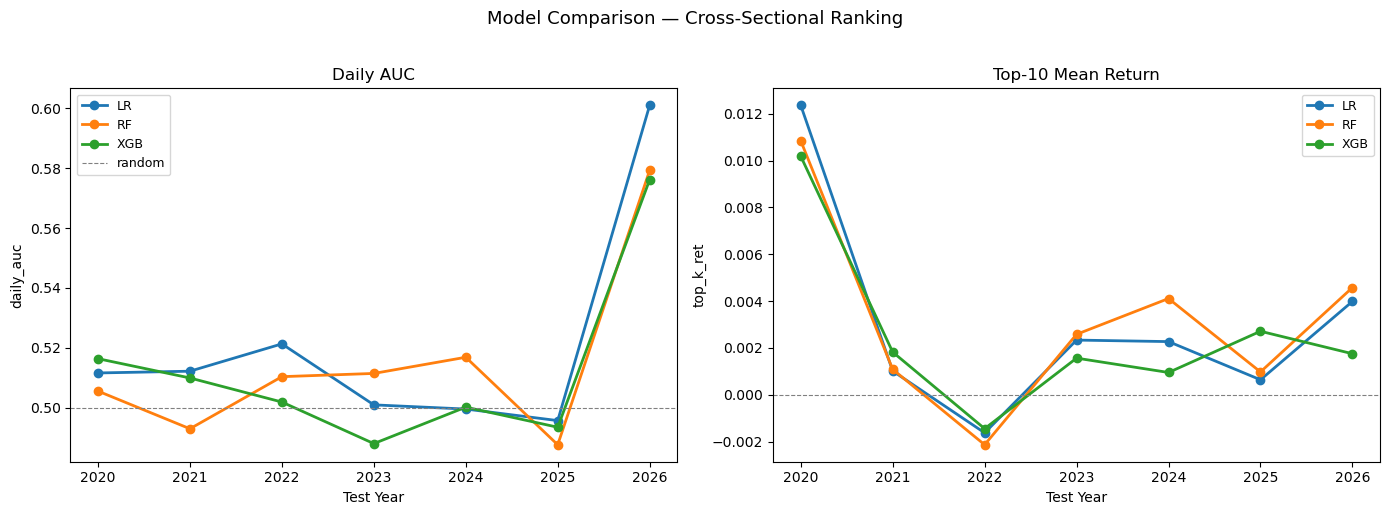

In [24]:
# 7.1 Daily AUC by fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], 'daily_auc', 'Daily AUC'),
    (axes[1], 'top_k_ret', f'Top-{cfg.strategy.top_k} Mean Return'),
]:
    for name in results_full['model'].unique():
        sub = results_full[results_full['model'] == name]
        ax.plot(sub['test_year'], sub[metric], 'o-', label=name, lw=2, markersize=6)
    if metric == 'daily_auc':
        ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='random')
    else:
        ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Test Year')
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Model Comparison — Cross-Sectional Ranking', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

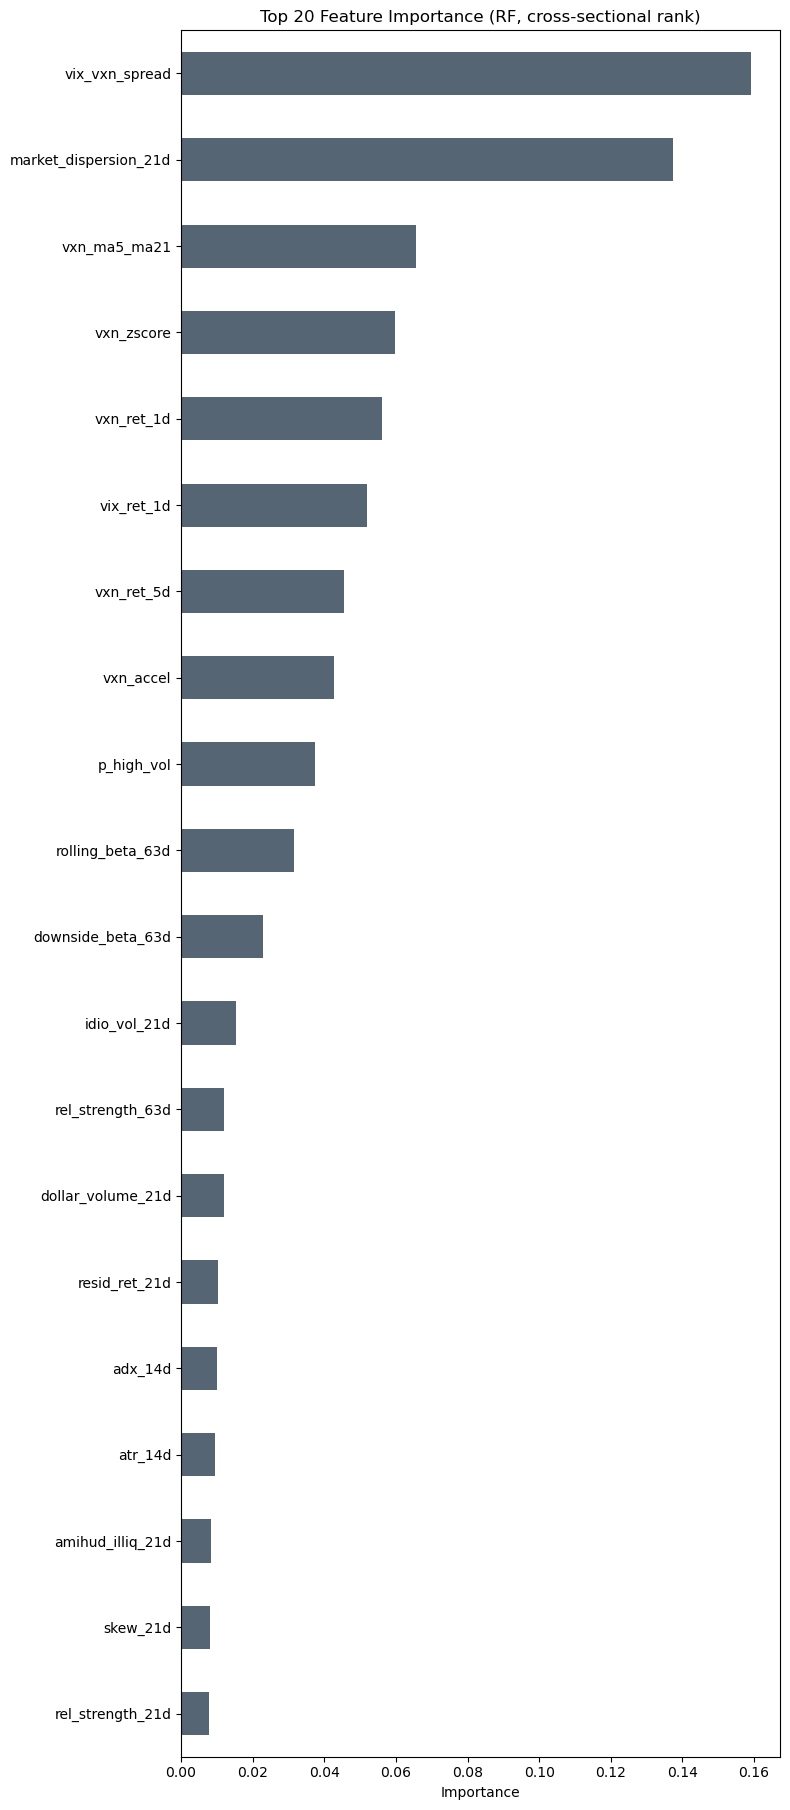

In [25]:
# 7.2 Feature importance (RF, last fold)
from src.models.train import cross_sectional_rank, _clean_raw

last_fold = splits[-1]
train_last = df.loc[last_fold.train_idx]

# Cross-sectional rank
train_ranked = cross_sectional_rank(train_last, feature_cols)
X_last = train_ranked[feature_cols].values.copy()
X_last, _ = _clean_raw(X_last)
y_last = train_last[TARGET].values.astype(int)

from sklearn.ensemble import RandomForestClassifier
rf_imp = RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=30,
    max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
)
rf_imp.fit(X_last, y_last)

imp = pd.Series(rf_imp.feature_importances_, index=feature_cols)
imp = imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(len(feature_cols) * 0.28, 8)))
imp.tail(20).plot.barh(ax=ax, color='#2c3e50', alpha=0.8)
ax.set_title('Top 20 Feature Importance (RF, cross-sectional rank)', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8 · Lưu kết quả

In [15]:
(cfg.dir_outputs / 'metrics').mkdir(parents=True, exist_ok=True)

# Metrics
results_full.to_csv(cfg.dir_outputs / 'metrics' / 'walkforward_full.csv', index=False)
results_base.to_csv(cfg.dir_outputs / 'metrics' / 'walkforward_base.csv', index=False)
print(f'✓ Saved walkforward metrics')

# Ensemble predictions
save(pred_ens_full, cfg.dir_processed / 'predictions_ens_full.parquet')
save(pred_ens_base, cfg.dir_processed / 'predictions_ens_base.parquet')
print(f'✓ Saved ensemble predictions (full + base)')

# Also save per-model predictions
save(pred_full, cfg.dir_processed / 'predictions_full.parquet')
save(pred_base, cfg.dir_processed / 'predictions_base.parquet')
print(f'✓ Saved per-model predictions')


✓ Saved walkforward metrics
✓ Saved ensemble predictions (full + base)
✓ Saved per-model predictions


In [3]:
# Verify
r1 = load(cfg.dir_processed / 'predictions_ens_full.parquet')
r2 = load(cfg.dir_processed / 'predictions_ens_base.parquet')
print(f'✓ Ensemble Full: {r1.shape}, cols={r1.columns.tolist()}')
print(f'✓ Ensemble Base: {r2.shape}, cols={r2.columns.tolist()}')
assert 'y_prob' in r1.columns
assert 'y_prob' in r2.columns
print(f'✓ Round-trip OK')


✓ Ensemble Full: (49303, 5), cols=['y_true', 'adj_close', 'y_prob', 'model', 'fold']
✓ Ensemble Base: (49303, 5), cols=['y_true', 'adj_close', 'y_prob', 'model', 'fold']
✓ Round-trip OK
